In [55]:
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV
import torch

# Загрузка датасета (2 класса)
categories = ['sci.space', 'comp.graphics']
newsgroups = fetch_20newsgroups(subset='train', categories=categories, remove=('headers', 'footers', 'quotes'))

# TF-IDF
vectorizer = TfidfVectorizer(max_features=200)
X = vectorizer.fit_transform(newsgroups.data).toarray()
y = LabelEncoder().fit_transform(newsgroups.target)

# Разделение данных
X_train, X_test, y_train, y_test, texts_train, texts_test = train_test_split(
    X, y, newsgroups.data, test_size=0.3, random_state=42
)

print("Размер обучающей выборки:", X_train.shape)

Размер обучающей выборки: (823, 200)


In [56]:
# Обучаем калиброванную модель для получения вероятностей
base_model = LogisticRegression(max_iter=1000)
calibrated_model = CalibratedClassifierCV(base_model, cv=3, method='sigmoid')
calibrated_model.fit(X_train, y_train)

# Получаем soft labels (вероятности)
soft_labels = calibrated_model.predict_proba(X_train)
soft_labels = torch.tensor(soft_labels, dtype=torch.float32)

print("Пример soft labels:", soft_labels[:2])

Пример soft labels: tensor([[0.8394, 0.1606],
        [0.8146, 0.1854]])


In [57]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class xLSTMBlock(nn.Module):
    def __init__(self, d_input, d_model):
        super().__init__()
        self.lstm = nn.LSTM(input_size=d_input, hidden_size=d_model, batch_first=True)
        self.out_proj = nn.Linear(d_model, d_input)

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        out = self.out_proj(lstm_out)
        return out, lstm_out  # Возвращаем и преобразованный выход, и скрытое состояние

class xLSTMModel(nn.Module):
    def __init__(self, num_layers, d_input, d_model, num_classes):
        super().__init__()
        self.layers = nn.ModuleList([xLSTMBlock(d_input, d_model) for _ in range(num_layers)])
        self.classifier = nn.Linear(d_input, num_classes)

    def forward(self, x, return_attention=False):
        attn_maps = []
        for layer in self.layers:
            x, hidden = layer(x)
            if return_attention:
                attn_maps.append(hidden)
        logits = self.classifier(x)
        if return_attention:
            return logits, attn_maps
        else:
            return logits

In [58]:
# Параметры модели
num_classes = 2
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Создаем модель
model = xLSTMModel(num_layers=2, d_input=200, d_model=128, num_classes=num_classes).to(device)

# Функция потерь: Kullback-Leibler Divergence
def kl_loss(outputs, targets):
    log_preds = F.log_softmax(outputs, dim=1)
    return F.kl_div(log_preds, targets, reduction='batchmean')

optimizer = torch.optim.Adam(model.parameters(), lr=3e-3)

# Преобразуем данные в тензоры
X_train_tensor = torch.tensor(X_train, dtype=torch.float32).to(device)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)
y_test_tensor = torch.tensor(y_test, dtype=torch.long).to(device)

Epoch 5/100, Loss: 0.3346
Epoch 10/100, Loss: 0.3274
Epoch 15/100, Loss: 0.2536
Epoch 20/100, Loss: 0.0608
Epoch 25/100, Loss: 0.0603
Epoch 30/100, Loss: 0.0278
Epoch 35/100, Loss: 0.0162
Epoch 40/100, Loss: 0.0074
Epoch 45/100, Loss: 0.0068
Epoch 50/100, Loss: 0.0040
Epoch 55/100, Loss: 0.0036
Epoch 60/100, Loss: 0.0027
Epoch 65/100, Loss: 0.0019
Epoch 70/100, Loss: 0.0014
Epoch 75/100, Loss: 0.0011
Epoch 80/100, Loss: 0.0009
Epoch 85/100, Loss: 0.0008
Epoch 90/100, Loss: 0.0006
Epoch 95/100, Loss: 0.0006
Epoch 100/100, Loss: 0.0005


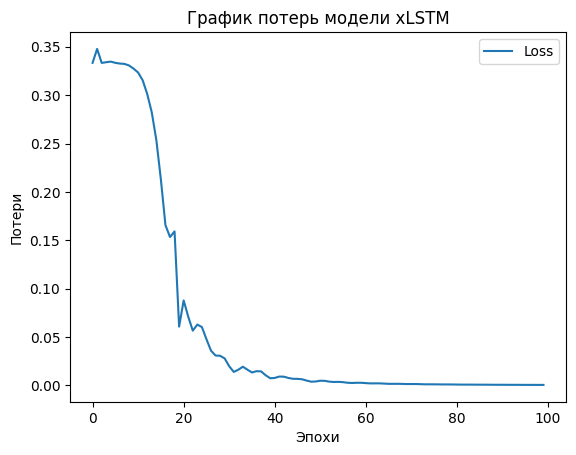

In [59]:
# Обучение
num_epochs = 100
losses = []

model.train()
for epoch in range(num_epochs):
    optimizer.zero_grad()
    logits = model(X_train_tensor)  # Только логиты, без attention
    loss = kl_loss(logits, soft_labels.to(device))
    loss.backward()
    optimizer.step()
    losses.append(loss.item())
    if (epoch + 1) % 5 == 0: print(f"Epoch {epoch+1}/{num_epochs}, Loss: {loss.item():.4f}")

# Визуализация потерь
import matplotlib.pyplot as plt

plt.plot(losses, label='Loss')
plt.title('График потерь модели xLSTM')
plt.xlabel('Эпохи')
plt.ylabel('Потери')
plt.legend()
plt.show()

In [60]:
def evaluate(model, X_test, y_test):
    model.eval()
    with torch.no_grad():
        outputs = model(X_test)
        _, predictions = torch.max(outputs, dim=1)
        accuracy = (predictions == y_test).float().mean()
    return accuracy.item()

accuracy = evaluate(model, X_test_tensor, y_test_tensor)
print(f'Финальная точность: {accuracy:.4f}')

Финальная точность: 0.8446


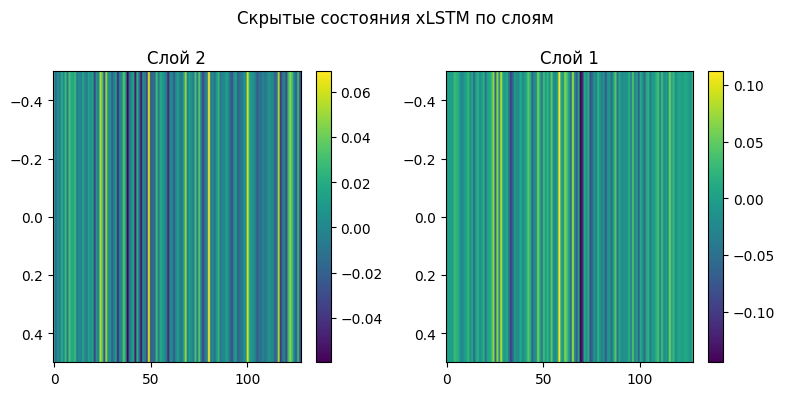

In [62]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# Переключаем модель в режим оценки
model.eval()

# Получаем выход модели и скрытые состояния
with torch.no_grad():
    _, attn_maps = model(X_test_tensor, return_attention=True)

# Определяем количество слоёв
num_layers = len(attn_maps)

# Создаём фигуру для отображения
fig, axes = plt.subplots(1, num_layers, figsize=(4 * num_layers, 4))

# Если только один слой, преобразуем axes в список для унификации
if num_layers == 1:
    axes = [axes]

# Проходим по каждому слою и строим изображение
for i, attn_map in enumerate(attn_maps):
    # Усредняем по батчу, оставляя размерность (seq_len, hidden_size)
    attn_map_np = attn_map.mean(dim=0).cpu().numpy()  # shape: (seq_len, hidden_size)

    # Если seq_len == 1 (не последовательность), добавляем размерность
    if attn_map_np.ndim == 1:
        attn_map_np = attn_map_np.reshape(1, -1)  # (1, hidden_size)

    ax = axes[i]
    im = ax.imshow(attn_map_np, cmap='viridis', aspect='auto')
    ax.set_title(f"Слой {i+1}")
    fig.colorbar(im, ax=ax)

plt.suptitle("Скрытые состояния xLSTM по слоям")
plt.tight_layout()
plt.show()

**Выводы**

* Слой 1: Выражены яркие вертикальные полосы (зелёные и жёлтые), что указывает на высокую активацию определённых признаков. Это означает, что первый слой LSTM чувствителен к конкретным словам или темам в текстах. Есть чёткие разделения между группами признаков, что говорит о локальной специализации нейронов на разных частях входных данных.


* Слой 2 : Распределение цветов более равномерное, с меньшим количеством экстремальных значений. Это указывает на обобщение информации из первого слоя: второй слой комбинирует и усредняет активации, выделяя более абстрактные признаки. Снижение дисперсии активаций может свидетельствовать о том, что глубинный слой фильтрует шум и концентрируется на ключевых сигналах

* Использование "мягких меток", сгенерированных калиброванной моделью, позволило повысить качество классификации, так как модель училась на вероятностных распределениях, а не на жёстких метках.

* LSTM-архитектура справилась с задачей бинарной классификации, демонстрируя адаптивность к последовательным данным (хотя входными данными были TF-IDF вектора, а не текстовые последовательности)

* Графики скрытых состояний подтверждают, что LSTM-слои различают важные признаки в данных. Первый слой фокусируется на локальных особенностях, а второй — на глобальных трендах.